# Training and Validate Evaluation

In [1]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
PROJECT_DIR = Path("/Users/minkhant/Downloads/Grad-CAM_CarDD")

NOTEBOOK_DIR = PROJECT_DIR / 'notebooks'
if not (NOTEBOOK_DIR / 'experiment_utils.py').is_file():
    raise FileNotFoundError('Set PROJECT_DIR to the vehicle-damage project directory.')
sys.path.insert(0, str(NOTEBOOK_DIR))
import tensorflow as tf
import experiment_utils as eu

OUTPUT_DIR = PROJECT_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
print('Python:', sys.executable)
print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('CPU execution is supported if no GPU is listed.')

Python: /Users/minkhant/Downloads/Grad-CAM_CarDD/.venv/bin/python
TensorFlow: 2.21.0
GPU devices: []
CPU execution is supported if no GPU is listed.


## Settings

In [3]:
SEED = 42
TARGET_SIZE = (224, 224)  # height, width; direct resize shared by every workflow
BATCH_SIZE = 32
HEAD_EPOCHS = 15
FINETUNE_EPOCHS = 20
HEAD_LR = 1e-3
FINETUNE_LR = 1e-5
THRESHOLDS = np.round(np.arange(0.05, 1.0, 0.05), 2)
TOP_K_THRESHOLDS = 5
SANITY_PER_CLASS = 2  # fixed validation sample: up to 12 crops total
GRADCAM_LAYER = eu.GRADCAM_LAYER
TARGET_MODE = 'ground_truth'  # localization of selected annotated instance

DATA_DIR = PROJECT_DIR / 'data'
PREPARED_DIR = PROJECT_DIR / 'processed' / 'padding_25pct_per_side'
MANIFEST_PATH = PREPARED_DIR / 'sample_manifest.csv'
tf.keras.utils.set_random_seed(SEED)
# Seeds reduce variability; hardware may prevent exact reproducibility.
run_name = datetime.now().strftime('run_%Y%m%d_%H%M%S_%f')
RUN_DIR = OUTPUT_DIR / run_name
RUN_DIR.mkdir()
print('Run output:', RUN_DIR)

Run output: /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762


## Dataset, annotations, class distribution and weights

loading annotations into memory...
Done (t=0.37s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


,crops,images
split,,
test,785,374
train,6211,2816
val,1744,810


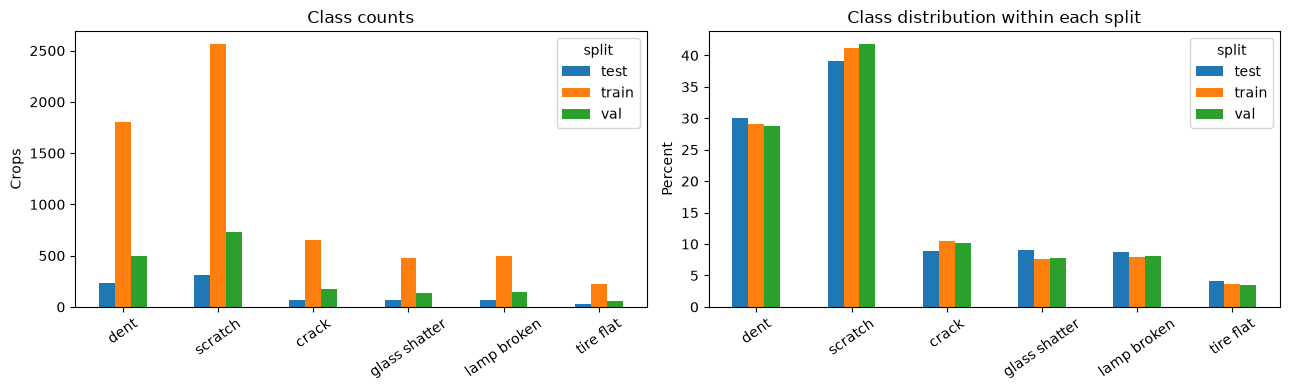

,class,weight
0,dent,0.573182
1,scratch,0.404362
2,crack,1.590118
3,glass shatter,2.179298
4,lamp broken,2.095479
5,tire flat,4.600741


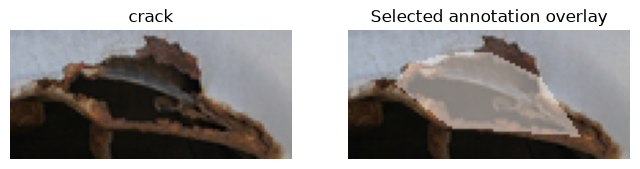

In [4]:
samples = eu.load_manifest(MANIFEST_PATH)
train_samples = samples.loc[samples.split == 'train'].reset_index(drop=True)
val_samples = samples.loc[samples.split == 'val'].reset_index(drop=True)
annotations = eu.load_annotations(DATA_DIR, splits=('train', 'val'))
display(samples.groupby('split').agg(crops=('sample_id', 'size'), images=('image_id', 'nunique')))
fig, class_counts = eu.plot_class_distribution(samples)
fig.savefig(RUN_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
class_weights = eu.calculate_class_weights(train_samples)
display(pd.DataFrame({'class': eu.CLASS_NAMES, 'weight': [class_weights[i] for i in range(6)]}))

# Verify that a representative crop and its selected mask are aligned.
example = val_samples.iloc[0]
crop = eu.load_crop(example)
mask = eu.load_damage_mask(example, annotations)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(crop); axes[0].set_title(example.category)
axes[1].imshow(crop); axes[1].imshow(np.ma.masked_where(~mask, mask), cmap='Reds', alpha=.5)
axes[1].set_title('Selected annotation overlay')
for ax in axes: ax.axis('off')
plt.show()

## Preprocessing and Experiment Record

In [5]:
train_ds = eu.make_dataset(train_samples, BATCH_SIZE, TARGET_SIZE, training=True, seed=SEED)
val_ds = eu.make_dataset(val_samples, BATCH_SIZE, TARGET_SIZE)
config = {
    'seed': SEED, 'target_size': list(TARGET_SIZE), 'batch_size': BATCH_SIZE,
    'head_epochs': HEAD_EPOCHS, 'finetune_epochs': FINETUNE_EPOCHS,
    'head_lr': HEAD_LR, 'finetune_lr': FINETUNE_LR, 'class_names': eu.CLASS_NAMES,
    'class_weights': class_weights, 'tensorflow_version': tf.__version__,
    'manifest_path': str(MANIFEST_PATH),
    'manifest_sha256': hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest(),
    'annotation_sha256': {s: hashlib.sha256((DATA_DIR / 'annotations' /
        f'instances_{folder}.json').read_bytes()).hexdigest() for s, folder in eu.SPLIT_FOLDERS.items()},
    'crop_config': json.loads((PREPARED_DIR / 'crop_config.json').read_text()),
    'preprocessing': 'RGB 0..255 -> bilinear direct resize -> resnet50.preprocess_input',
    'augmentation': 'horizontal flip, rotation +/-0.03 turns, contrast +/-0.15',
    'finetuned_layers': 'conv5 and class_logits; all BatchNormalization frozen',
    'checkpoint_selection': 'minimum validation loss across both stages',
    'gradcam_layer': GRADCAM_LAYER, 'target_mode': TARGET_MODE,
    'candidate_thresholds': THRESHOLDS.tolist(), 'sanity_per_class': SANITY_PER_CLASS,
}
eu.save_json(RUN_DIR / 'training_config.json', config)


## Load ResNet50 and add the six-class head

In [6]:
model = eu.build_resnet50(TARGET_SIZE, len(eu.CLASS_NAMES))
eu.configure_fine_tuning(model, fine_tune=False, learning_rate=HEAD_LR)
model.summary()

def stage_callbacks(checkpoint, learning_rate):
    return [
        tf.keras.callbacks.ModelCheckpoint(str(checkpoint), monitor='val_loss',
                                           save_best_only=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=.5, patience=3,
                                            min_lr=learning_rate / 100, verbose=1),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

head_history = model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
    class_weight=class_weights, shuffle=False,
    callbacks=stage_callbacks(RUN_DIR / 'head_best.keras', HEAD_LR))
histories = {'head': head_history.history}
eu.save_json(RUN_DIR / 'training_history.json', histories)

Model: "damage_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

...

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.8427 - loss: 0.2365
Epoch 13: val_loss improved from 0.41866 to 0.41513, saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/head_best.keras

Epoch 13: finished saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/head_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.8427 - loss: 0.2365 - val_accuracy: 0.8486 - val_loss: 0.4151 - learning_rate: 5.0000e-04
Epoch 14/15


I0000 00:00:1791377634.344117 74683360 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 948 of 6211
I0000 00:00:1791377644.350440 74683360 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1938 of 6211
I0000 00:00:1791377664.342432 74683360 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4099 of 6211
I0000 00:00:1791377684.338064 74683360 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 6180 of 6211
I0000 00:00:1791377684.679395 74683360 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.8438 - loss: 0.2253
Epoch 14: val_loss did not improve from 0.41513
195/195 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8438 - loss: 0.2253 - val_accuracy: 0.8331 - val_loss: 0.4560 - learning_rate: 5.0000e-04
Epoch 15/15


I0000 00:00:1791377917.301318 74703980 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 966 of 6211
I0000 00:00:1791377937.299997 74703980 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 3032 of 6211
I0000 00:00:1791377957.303165 74703980 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5152 of 6211
I0000 00:00:1791377967.602875 74703980 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.8507 - loss: 0.2260
Epoch 15: val_loss improved from 0.41513 to 0.41487, saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/head_best.keras

Epoch 15: finished saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/head_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8507 - loss: 0.2260 - val_accuracy: 0.8383 - val_loss: 0.4149 - learning_rate: 5.0000e-04


## Fine-tune the final ResNet stage

Epoch 1/20


I0000 00:00:1791378199.241447 74723362 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 951 of 6211
I0000 00:00:1791378209.243319 74723362 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1926 of 6211
I0000 00:00:1791378219.246130 74723362 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2981 of 6211
I0000 00:00:1791378239.246554 74723362 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5148 of 6211
I0000 00:00:1791378249.500792 74723362 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8569 - loss: 0.2133
Epoch 1: val_loss improved from None to 0.38214, saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/finetune_best.keras

Epoch 1: finished saving model to /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/finetune_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8569 - loss: 0.2133 - val_accuracy: 0.8589 - val_loss: 0.3821 - learning_rate: 1.0000e-05
Epoch 2/20


I0000 00:00:1791378554.219109 74746522 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 974 of 6211
I0000 00:00:1791378574.213059 74746522 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2973 of 6211
I0000 00:00:1791378594.217666 74746522 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5089 of 6211
I0000 00:00:1791378605.201906 74746522 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8834 - loss: 0.1739
Epoch 2: val_loss did not improve from 0.38214
195/195 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.8834 - loss: 0.1739 - val_accuracy: 0.8578 - val_loss: 0.3959 - learning_rate: 1.0000e-05
Epoch 3/20


...

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9762 - loss: 0.0336
Epoch 18: val_loss did not improve from 0.37252

Epoch 18: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-07.
195/195 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.9762 - loss: 0.0336 - val_accuracy: 0.8859 - val_loss: 0.4179 - learning_rate: 6.2500e-07
Epoch 19/20


I0000 00:00:1791384950.531860 75214602 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 874 of 6211
I0000 00:00:1791384960.534559 75214602 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1796 of 6211
I0000 00:00:1791384970.537370 75214602 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2761 of 6211
I0000 00:00:1791384990.530735 75214602 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4745 of 6211
I0000 00:00:1791385000.535219 75214602 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5701 of 6211
I0000 00:00:1791385006.092383 75214602 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9768 - loss: 0.0318
Epoch 19: val_loss did not improve from 0.37252
195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9768 - loss: 0.0318 - val_accuracy: 0.8847 - val_loss: 0.4204 - learning_rate: 3.1250e-07
Epoch 20/20


I0000 00:00:1791385312.122546 75238544 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 916 of 6211
I0000 00:00:1791385322.124103 75238544 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1874 of 6211
I0000 00:00:1791385332.127799 75238544 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2877 of 6211
I0000 00:00:1791385352.123289 75238544 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 4957 of 6211
I0000 00:00:1791385362.129849 75238544 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 5944 of 6211
I0000 00:00:1791385365.040454 75238544 shuffle_dataset_op.cc:483] Shuffle buffer filled.


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9763 - loss: 0.0339
Epoch 20: val_loss did not improve from 0.37252
195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9763 - loss: 0.0339 - val_accuracy: 0.8853 - val_loss: 0.4219 - learning_rate: 3.1250e-07
Selected stage: finetune


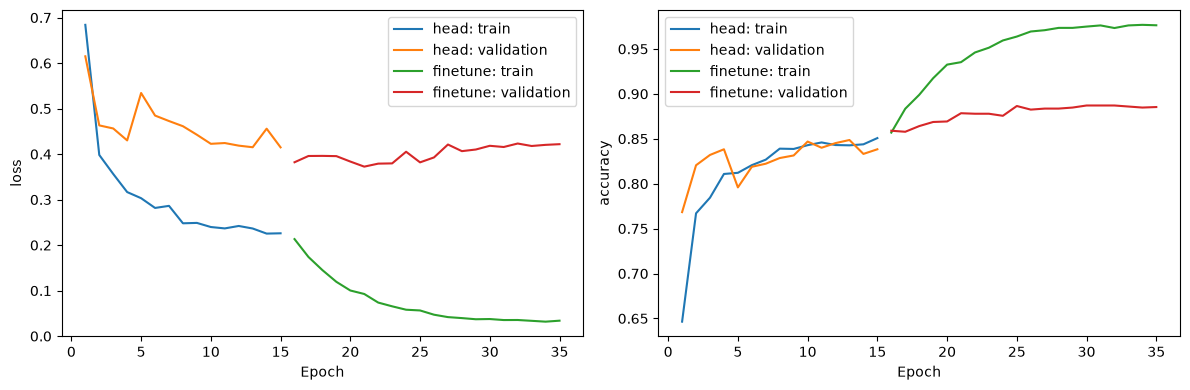

In [7]:
model = tf.keras.models.load_model(RUN_DIR / 'head_best.keras', compile=False)
eu.configure_fine_tuning(model, fine_tune=True, learning_rate=FINETUNE_LR)
finetune_history = model.fit(train_ds, validation_data=val_ds, epochs=FINETUNE_EPOCHS,
    class_weight=class_weights, shuffle=False,
    callbacks=stage_callbacks(RUN_DIR / 'finetune_best.keras', FINETUNE_LR))
histories['finetune'] = finetune_history.history
eu.save_json(RUN_DIR / 'training_history.json', histories)

head_loss = min(histories['head']['val_loss'])
finetune_loss = min(histories['finetune']['val_loss'])
best_stage = 'head' if head_loss <= finetune_loss else 'finetune'
model = tf.keras.models.load_model(RUN_DIR / f'{best_stage}_best.keras', compile=False)
model.save(RUN_DIR / 'best_model.keras')
eu.save_json(RUN_DIR / 'model_selection.json', {
    'best_stage': best_stage, 'head_best_val_loss': head_loss,
    'finetune_best_val_loss': finetune_loss})
print('Selected stage:', best_stage)
fig = eu.plot_training_history(histories)
fig.savefig(RUN_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step 


accuracy              0.878440
macro_precision       0.893834
weighted_precision    0.878326
macro_recall          0.919376
weighted_recall       0.878440
macro_f1              0.905600
weighted_f1           0.877701
dtype: float64

,class,precision,recall,f1,support
0,dent,0.867521,0.810379,0.837977,501
1,scratch,0.876543,0.877747,0.877145,728
2,crack,0.830601,0.858757,0.844444,177
3,glass shatter,0.971014,0.992593,0.981685,135
4,lamp broken,0.864198,0.992908,0.924092,141
5,tire flat,0.953125,0.983871,0.968254,62


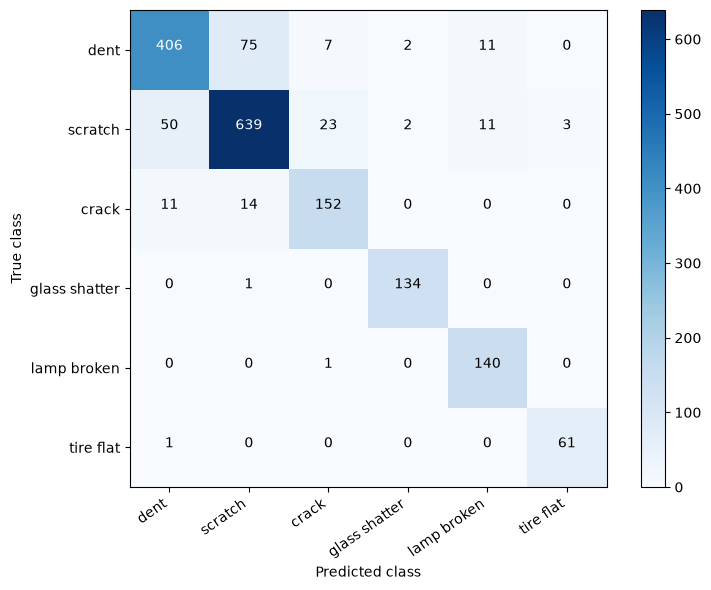

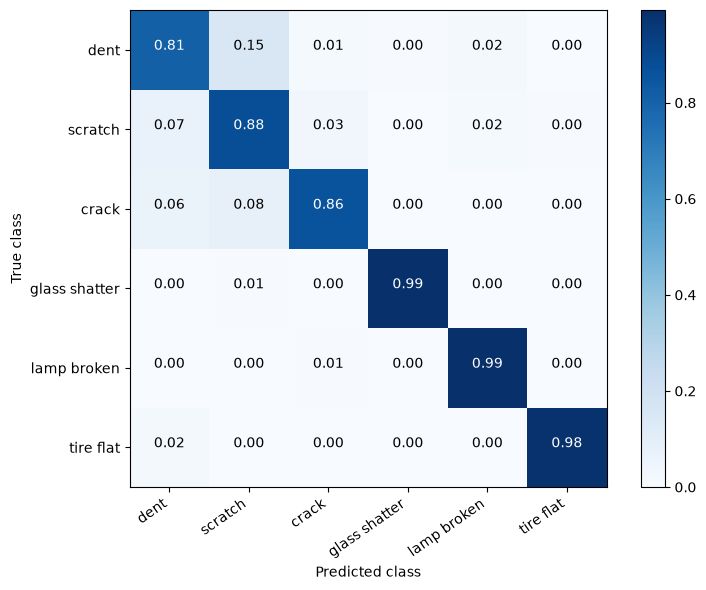

In [8]:
val_predictions, val_report, val_metrics, val_cm = eu.evaluate_classification(model, val_ds, val_samples)
val_predictions.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)
val_report.to_csv(RUN_DIR / 'validation_classification_report.csv', index=False)
eu.save_json(RUN_DIR / 'validation_classification_metrics.json', val_metrics)
np.save(RUN_DIR / 'validation_confusion_matrix.npy', val_cm)
display(pd.Series(val_metrics)); display(val_report)
for normalized in (False, True):
    fig = eu.plot_confusion_matrix(val_cm, normalize=normalized)
    fig.savefig(RUN_DIR / f'validation_confusion_matrix_{normalized}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Grad-CAM

In [9]:
val_cache = eu.collect_gradcam(model, val_samples, TARGET_SIZE, BATCH_SIZE,
                              target_mode=TARGET_MODE, layer_name=GRADCAM_LAYER)
np.savez_compressed(RUN_DIR / 'validation_gradcam.npz', **val_cache)
val_localization, threshold_ranking = eu.select_validation_threshold(
    val_samples, annotations, val_cache, THRESHOLDS)
val_localization.to_csv(RUN_DIR / 'validation_localization.csv', index=False)
threshold_ranking.to_csv(RUN_DIR / 'validation_threshold_ranking.csv', index=False)
selected_threshold = float(threshold_ranking.iloc[0].threshold)
protocol = {
    'selected_threshold': selected_threshold, 'selection_split': 'val',
    'selection_metric': 'mean sample IoU', 'tie_break': 'lower threshold',
    'top_five_thresholds': threshold_ranking.head(TOP_K_THRESHOLDS).threshold.tolist(),
    'target_mode': TARGET_MODE, 'layer_name': GRADCAM_LAYER,
    'localization_resolution': 'original crop',
    'invalid_heatmaps': 'IoU zero and pointing miss',
    'pointing_ties': 'first row-major maximum',
}
eu.save_json(RUN_DIR / 'evaluation_protocol.json', protocol)
# Evaluation defaults to this completed model/threshold run; you can override its path.
eu.save_json(OUTPUT_DIR / 'latest_run.json', {'run_dir': str(RUN_DIR.resolve())})
display(threshold_ranking.head(TOP_K_THRESHOLDS))
print('Automatically selected IoU threshold:', selected_threshold)
print('Pointing accuracy:', float(threshold_ranking.iloc[0].pointing_accuracy))

per_class = val_localization.loc[val_localization.threshold == selected_threshold].groupby('category').agg(
    mean_iou=('iou', 'mean'), pointing_accuracy=('pointing_hit', 'mean'), samples=('sample_id', 'size'))
per_class.to_csv(RUN_DIR / 'validation_localization_per_class.csv')
display(per_class)


Grad-CAM: 32/1744
Grad-CAM: 320/1744
Grad-CAM: 640/1744
Grad-CAM: 960/1744
Grad-CAM: 1280/1744
Grad-CAM: 1600/1744
Grad-CAM: 1744/1744


,threshold,mean_iou,pointing_accuracy,informative_fraction,samples,whole_crop_mean_iou,macro_class_iou
0,0.20,0.378361,0.695528,1.0,1744,0.309274,0.447870
1,0.25,0.378307,0.695528,1.0,1744,0.309274,0.446458
2,0.15,0.373505,0.695528,1.0,1744,0.309274,0.443612
3,0.30,0.372816,0.695528,1.0,1744,0.309274,0.439400
4,0.10,0.364657,0.695528,1.0,1744,0.309274,0.433620


Automatically selected IoU threshold: 0.2
Pointing accuracy: 0.6955275229357798


,mean_iou,pointing_accuracy,samples
category,,,
crack,0.221886,0.480226,177
dent,0.396460,0.734531,501
glass shatter,0.627825,0.962963,135
lamp broken,0.610954,0.971631,141
scratch,0.299692,0.596154,728
tire flat,0.530401,0.951613,62


## Calculate Best Threshold

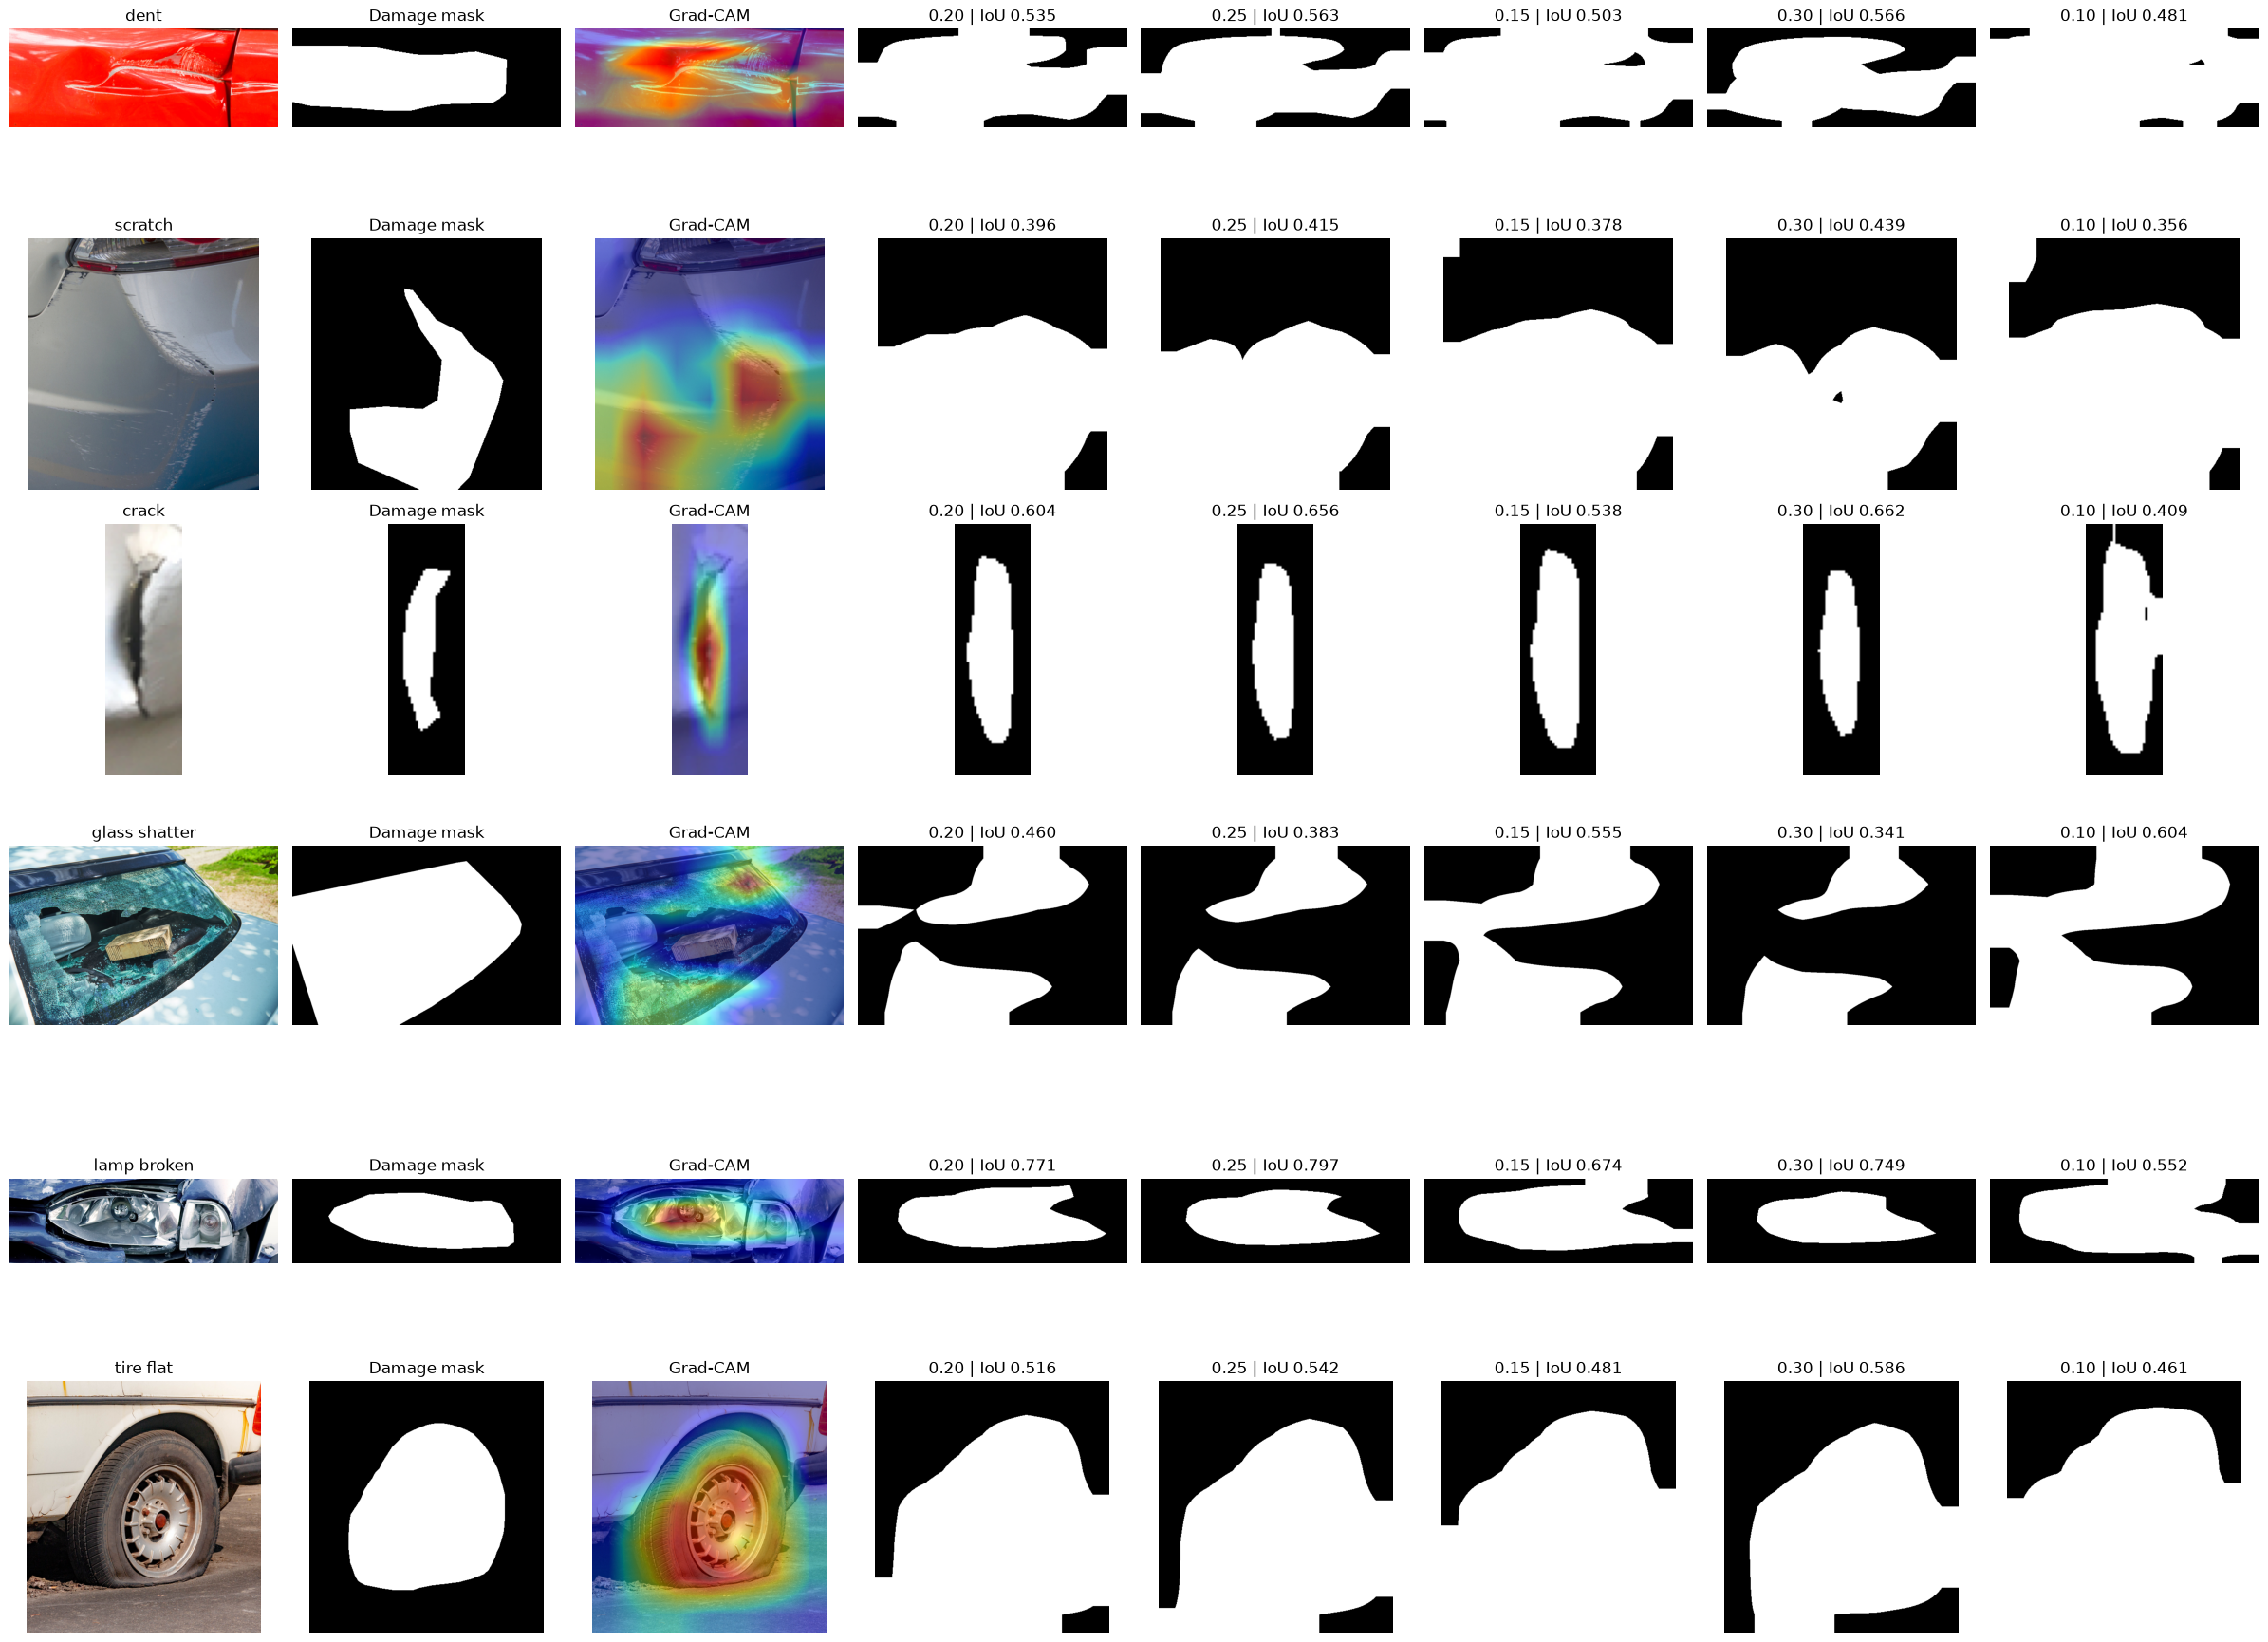

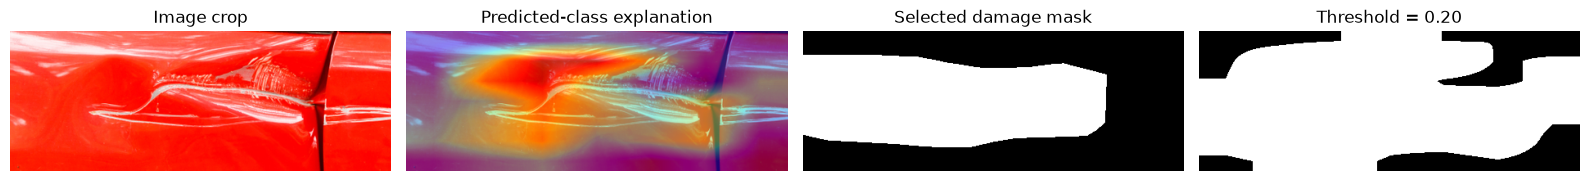

In [10]:
gallery = eu.balanced_sample(val_samples, per_class=1, seed=SEED)
gallery_cache = eu.subset_cache(gallery, val_cache)
fig = eu.plot_threshold_comparison(gallery, annotations, gallery_cache,
                                   threshold_ranking.head(TOP_K_THRESHOLDS).threshold)
fig.savefig(RUN_DIR / 'validation_top_five_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()
# Example explanation for the model's prediction, useful for inspecting errors.
row = gallery.iloc[0]
crop = eu.load_crop(row)
predicted_heatmap = eu.generate_gradcam(model, crop, target_size=TARGET_SIZE)
fig = eu.plot_gradcam(crop, predicted_heatmap, eu.load_damage_mask(row, annotations),
                     selected_threshold, title='Predicted-class explanation')
plt.show()

## Sanity Check

Sanity head: 12/12
Sanity conv5: 12/12
Sanity conv4: 12/12
Sanity conv3: 12/12
Sanity conv2: 12/12
Sanity conv1: 12/12


,stage,mean_spearman,mean_mae,valid_correlations,samples,randomized_informative_fraction
0,head,0.199070,0.243645,12,12,1.000000
1,conv5,-0.088095,0.283826,12,12,1.000000
2,conv4,0.044370,0.291851,8,12,0.666667
3,conv3,-0.090807,0.303209,10,12,0.833333
4,conv2,-0.088925,0.336203,8,12,0.666667
5,conv1,0.132609,0.304990,8,12,0.666667


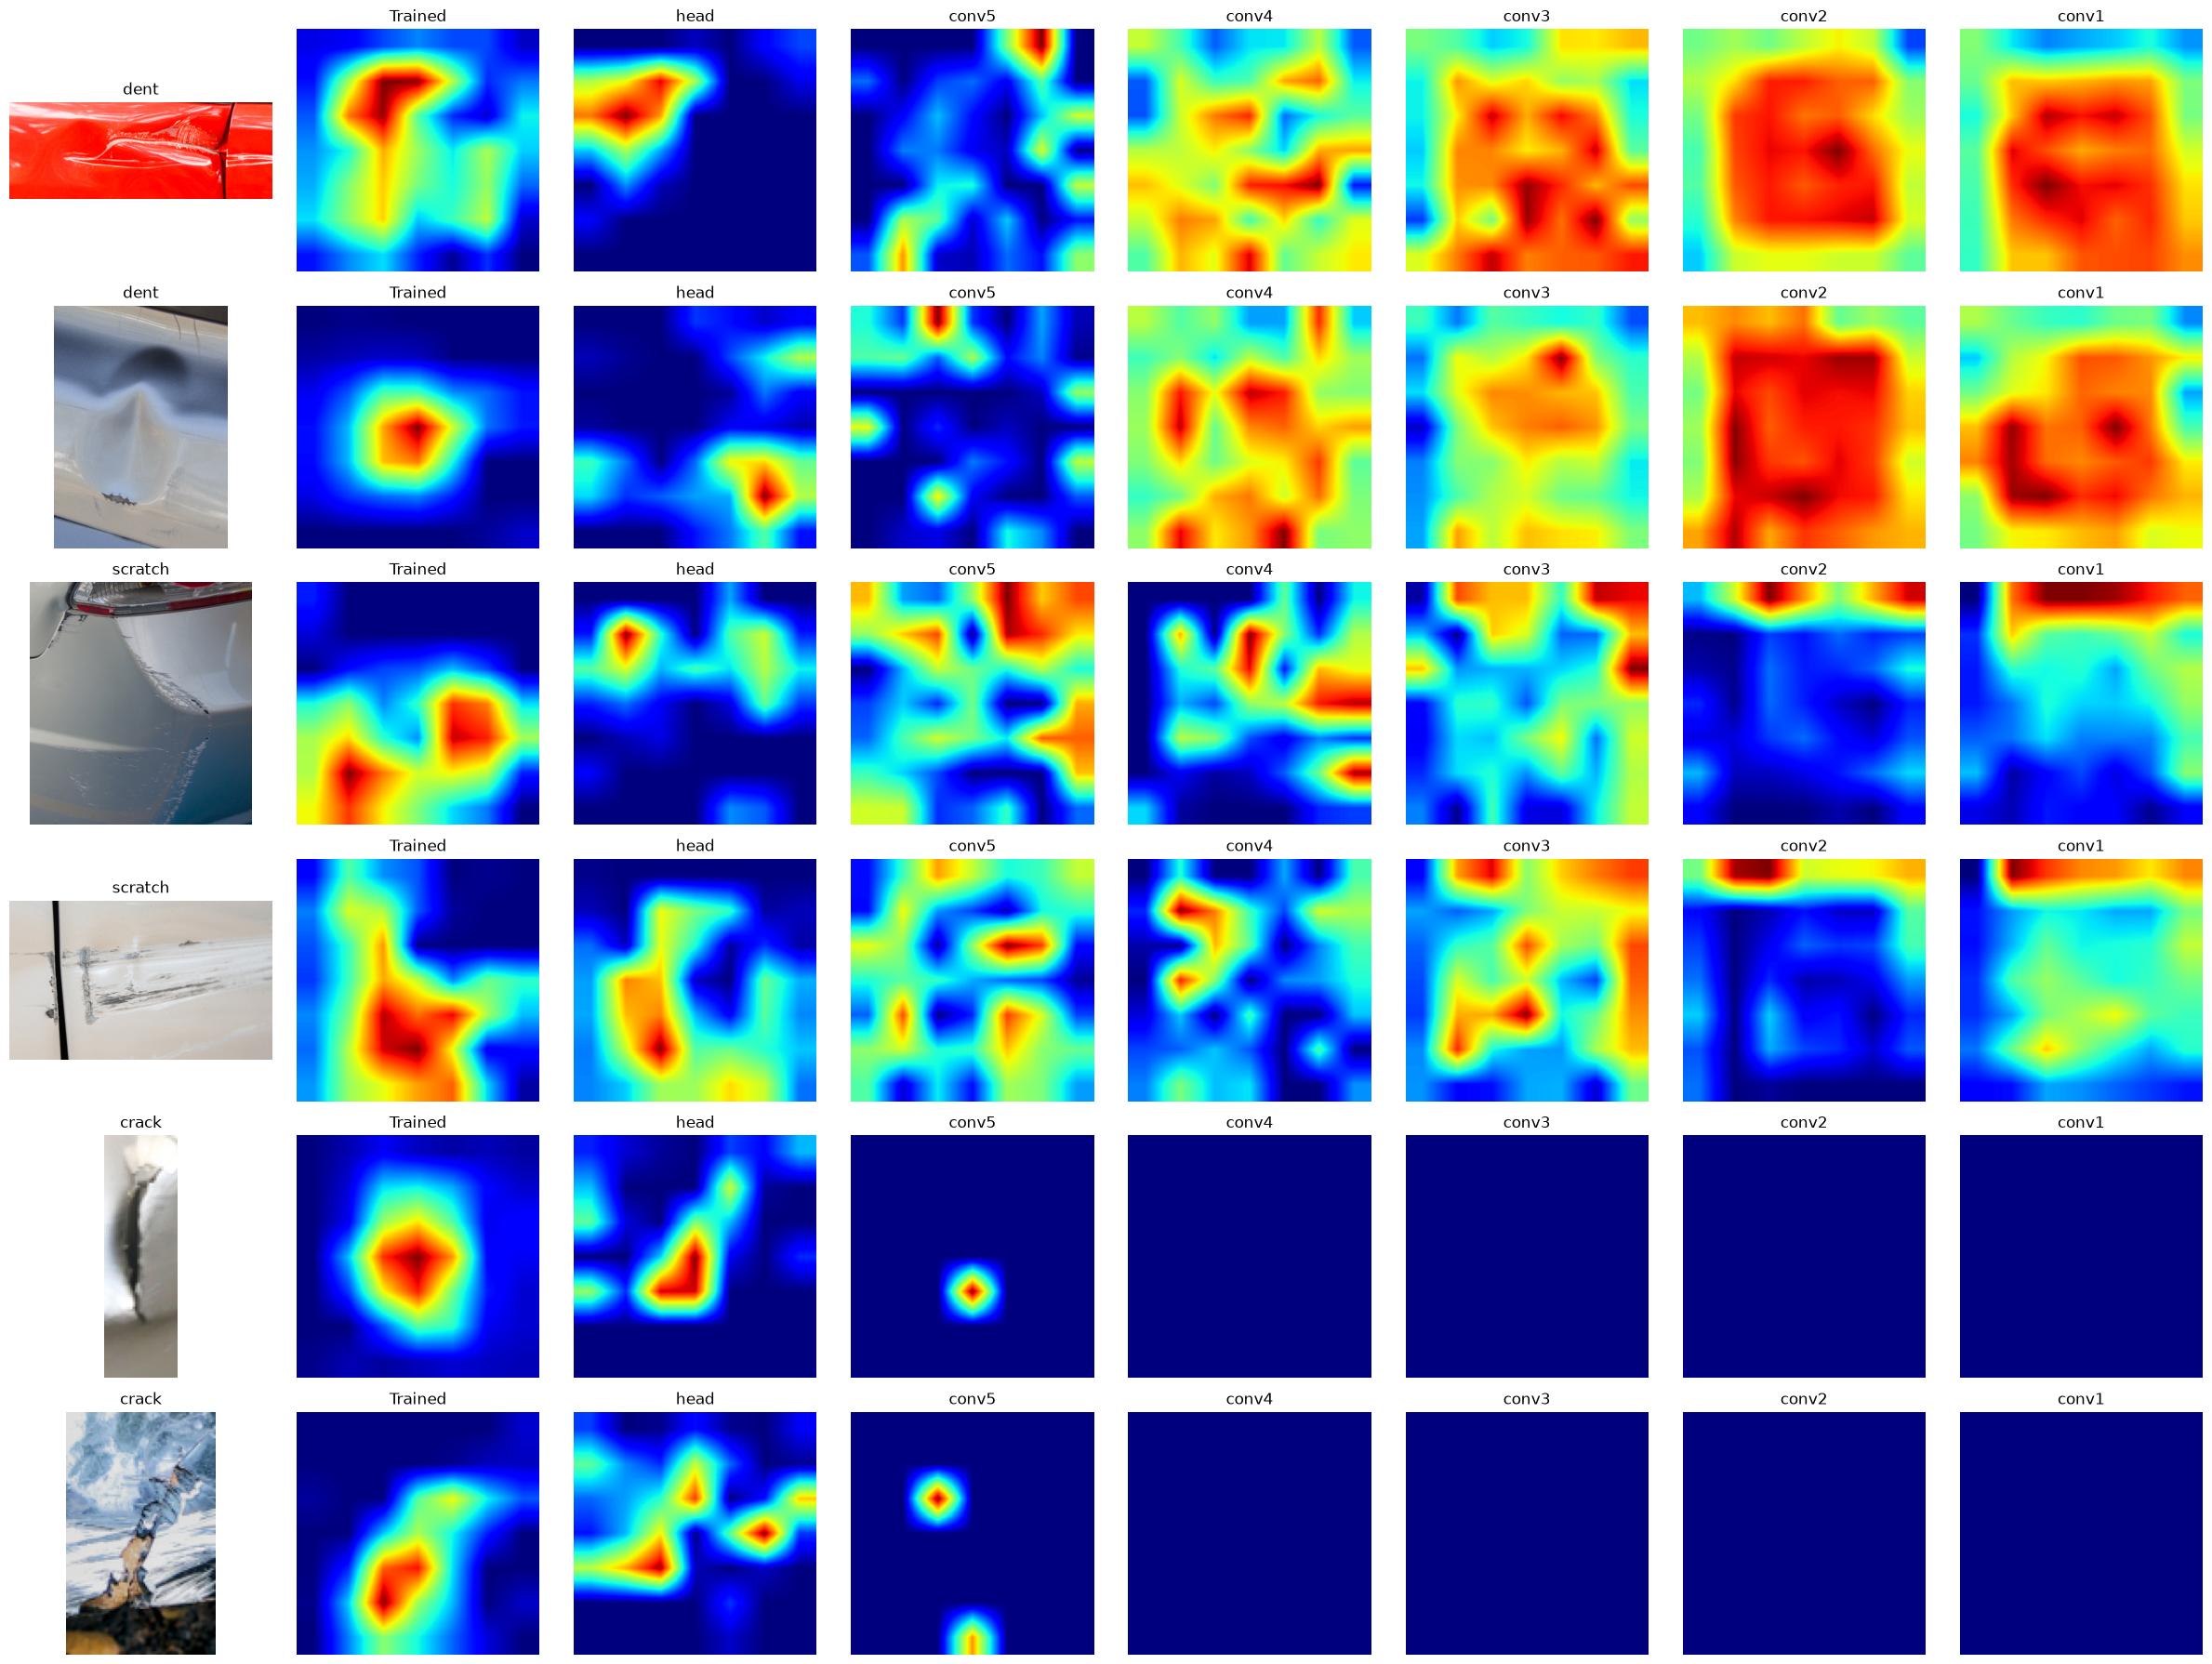

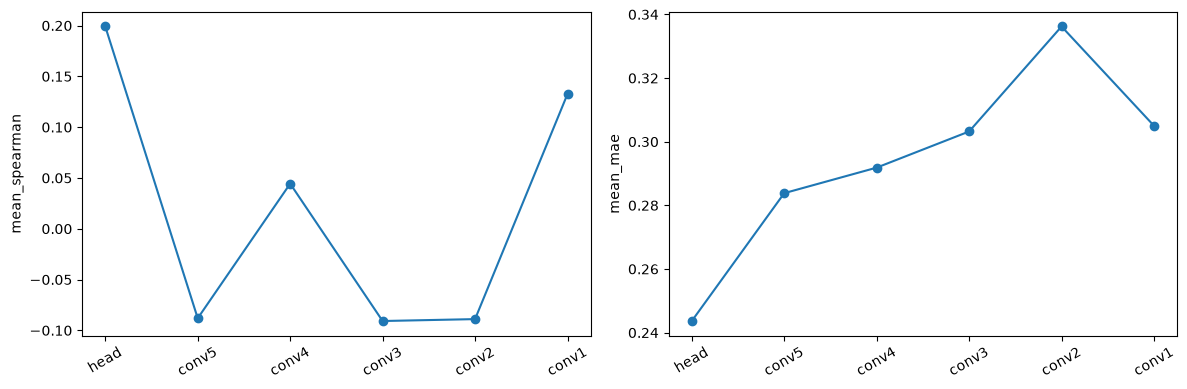

Training and validation artifacts saved to: /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762


In [11]:
sanity_samples = eu.balanced_sample(val_samples, SANITY_PER_CLASS, SEED)
sanity_samples.to_csv(RUN_DIR / 'validation_sanity_samples.csv', index=False)
sanity_baseline = eu.subset_cache(sanity_samples, val_cache)
sanity_results, sanity_summary, sanity_previews = eu.run_randomization_sanity_check(
    model, sanity_samples, TARGET_SIZE, BATCH_SIZE, GRADCAM_LAYER, SEED,
    baseline_cache=sanity_baseline, output_dir=RUN_DIR / 'validation_sanity')
display(sanity_summary)
for name, fig in zip(('heatmaps', 'metrics'), eu.plot_sanity_results(
        sanity_samples, sanity_baseline, sanity_summary, sanity_previews, TARGET_SIZE)):
    fig.savefig(RUN_DIR / 'validation_sanity' / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Training and validation artifacts saved to:', RUN_DIR)
